# Weekly HMM-Informed LSTM Classifier

This notebook tests whether adding weekly HMM-derived regime probabilities improves the baseline weekly LSTM classifier.

The HMM is not refitted here. The notebook loads the causal next-step HMM probabilities saved by `hmm_regime_weekly.ipynb`, merges them into the scaled weekly LSTM dataframe, trains the same small LSTM classifier across the ticker/lookback grid, and compares the results against naive benchmarks, the baseline weekly LSTM, and the HMM-only classifier.

In [12]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

from weekly_lstm_architecture import (
    WeeklyLSTMConfig,
    build_weekly_lstm_classifier,
    get_weekly_callbacks,
    set_global_seed,
)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

SEED = 42
set_global_seed(SEED)

In [13]:
PROJECT_ROOT = Path.cwd()

WEEKLY_SCALED_PATH = PROJECT_ROOT / "outputs" / "weekly" / "model_df_weekly_scaled.parquet"
HMM_FEATURE_SOURCE_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_regime_features.parquet"
BASELINE_LSTM_RESULTS_PATH = PROJECT_ROOT / "outputs" / "weekly_lstm" / "weekly_lstm_results.csv"
HMM_ONLY_RESULTS_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_only_results.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weekly_hmm_lstm"
SEQUENCE_DIR = OUTPUT_DIR / "sequences"
PLOTS_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = PROJECT_ROOT / "models" / "weekly_hmm_lstm"

for directory in [OUTPUT_DIR, SEQUENCE_DIR, PLOTS_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TICKERS = ["AAPL", "IBM", "MSFT"]
LOOKBACK_GRID = [4, 8, 12, 26]
EXPECTED_TRAINING_RUNS = len(TICKERS) * len(LOOKBACK_GRID)

WEEKLY_LSTM_FEATURE_COLS = [
    "Weekly_Log_Return",
    "Weekly_Open_Close_Log_Return",
    "Weekly_High_Low_Range",
    "Weekly_Volume_Change",
    "Rolling_Vol_4",
    "Rolling_Vol_12",
    "Rolling_Vol_26",
    "Momentum_4",
    "Momentum_12",
    "Momentum_26",
    "MA_Gap_4",
    "MA_Gap_12",
    "MA_Gap_26",
    "Drawdown_12",
    "Drawdown_26",
]

HMM_LSTM_FEATURE_COLS = [
    "HMM_Bullish_Prob_Next",
    "HMM_Positive_Return_Prob_Next",
]

AUGMENTED_LSTM_FEATURE_COLS = WEEKLY_LSTM_FEATURE_COLS + HMM_LSTM_FEATURE_COLS
EXPECTED_FEATURE_COUNT = 17

MERGE_KEYS = ["Ticker", "Date", "Target_Date", "Split"]
TARGET_COL = "Target_State_Binary"
LOW_PROBABILITY_STD_CUTOFF = 0.01

EPOCHS = 80
BATCH_SIZE = 16
PATIENCE = 12
THRESHOLDS = np.round(np.arange(0.05, 0.951, 0.01), 2)

if len(AUGMENTED_LSTM_FEATURE_COLS) != EXPECTED_FEATURE_COUNT:
    raise ValueError(f"Expected {EXPECTED_FEATURE_COUNT} features, found {len(AUGMENTED_LSTM_FEATURE_COLS)}")

target_like_cols = {"Target_State_Binary", "Target_State", "Next_Week_Log_Return"}
bad_feature_cols = [col for col in AUGMENTED_LSTM_FEATURE_COLS if col in target_like_cols or col.lower().startswith("target")]
if bad_feature_cols:
    raise ValueError(f"Target-like columns cannot be used as features: {bad_feature_cols}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Augmented feature count: {len(AUGMENTED_LSTM_FEATURE_COLS)}")

Project root: d:\BA_year_3\honour project
Output directory: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm
Augmented feature count: 17


## Load and Merge HMM Features

The merge uses only `Ticker`, `Date`, `Target_Date`, and `Split` as keys. Only the two causal next-step HMM features are brought into the scaled weekly LSTM dataframe.

In [14]:
def require_columns(df: pd.DataFrame, required_cols: list[str], name: str) -> None:
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")


required_scaled_cols = MERGE_KEYS + [
    "Next_Week_Log_Return",
    "Target_State_Binary",
    "Target_State",
] + WEEKLY_LSTM_FEATURE_COLS

required_hmm_cols = MERGE_KEYS + HMM_LSTM_FEATURE_COLS

weekly_scaled_df = pd.read_parquet(WEEKLY_SCALED_PATH)
hmm_feature_df = pd.read_parquet(HMM_FEATURE_SOURCE_PATH)

for df in [weekly_scaled_df, hmm_feature_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df["Target_Date"] = pd.to_datetime(df["Target_Date"])

require_columns(weekly_scaled_df, required_scaled_cols, "model_df_weekly_scaled")
require_columns(hmm_feature_df, required_hmm_cols, "weekly_hmm_regime_features")

original_row_count = len(weekly_scaled_df)

model_df_weekly_hmm_lstm = weekly_scaled_df.merge(
    hmm_feature_df[required_hmm_cols],
    on=MERGE_KEYS,
    how="left",
    validate="one_to_one",
)

if len(model_df_weekly_hmm_lstm) != original_row_count:
    raise ValueError(
        f"Merge changed row count: {original_row_count} -> {len(model_df_weekly_hmm_lstm)}"
    )

missing_feature_counts = model_df_weekly_hmm_lstm[AUGMENTED_LSTM_FEATURE_COLS].isna().sum()
if missing_feature_counts.sum() > 0:
    raise ValueError(f"Missing values found in final features:\n{missing_feature_counts[missing_feature_counts > 0]}")

for col in HMM_LSTM_FEATURE_COLS:
    if not model_df_weekly_hmm_lstm[col].between(0, 1).all():
        raise ValueError(f"{col} must be bounded between 0 and 1.")

model_df_weekly_hmm_lstm = model_df_weekly_hmm_lstm.sort_values(["Ticker", "Date"]).reset_index(drop=True)

model_df_weekly_hmm_lstm.to_parquet(OUTPUT_DIR / "model_df_weekly_hmm_lstm.parquet", index=False)
model_df_weekly_hmm_lstm.to_csv(OUTPUT_DIR / "model_df_weekly_hmm_lstm.csv", index=False)

print(model_df_weekly_hmm_lstm.shape)
display(model_df_weekly_hmm_lstm[MERGE_KEYS + HMM_LSTM_FEATURE_COLS].head())

(2424, 31)


,Ticker,Date,Target_Date,Split,HMM_Bullish_Prob_Next,HMM_Positive_Return_Prob_Next
0,AAPL,2010-07-09,2010-07-16,train,0.905658,0.656694
1,AAPL,2010-07-16,2010-07-23,train,0.734855,0.618643
2,AAPL,2010-07-23,2010-07-30,train,0.747023,0.621354
3,AAPL,2010-07-30,2010-08-06,train,0.747997,0.621571
4,AAPL,2010-08-06,2010-08-13,train,0.790824,0.631112


## Scaling Decision

The original technical features are standardized using training data only in `model_df_weekly_scaled.parquet`. The HMM features are probabilities in `[0, 1]`, so they are kept on their natural scale in this first HMM-informed LSTM version.

## Sequence Creation

Sequences are built separately per ticker and sorted chronologically by `Date`. For a target row at position `i`, the sequence uses rows `i - lookback + 1` through `i`, including the current week. The target is `Target_State_Binary` at row `i`, and the split is determined by the target row.

Validation and test sequences may include earlier rows from previous splits as input history, because those rows are in the past relative to the target row.

In [15]:
def create_hmm_lstm_sequences(
    df: pd.DataFrame,
    feature_cols: list[str],
    lookback: int,
    target_col: str = "Target_State_Binary",
):
    if lookback < 1:
        raise ValueError("lookback must be at least 1")

    split_order = ["train", "validation", "test"]
    X_by_split = {split: [] for split in split_order}
    y_by_split = {split: [] for split in split_order}
    sequence_info_rows = []

    for ticker, df_ticker in df.groupby("Ticker", sort=True):
        df_ticker = df_ticker.sort_values("Date").reset_index(drop=True)
        feature_matrix = df_ticker[feature_cols].to_numpy(dtype=np.float32)
        target_values = df_ticker[target_col].to_numpy(dtype=np.int64)

        for i in range(lookback - 1, len(df_ticker)):
            target_split = df_ticker.loc[i, "Split"]
            if target_split not in X_by_split:
                raise ValueError(f"Unexpected split value: {target_split}")

            X_by_split[target_split].append(feature_matrix[i - lookback + 1 : i + 1])
            y_by_split[target_split].append(target_values[i])
            sequence_info_rows.append(
                {
                    "Ticker": ticker,
                    "Lookback": lookback,
                    "Date": df_ticker.loc[i, "Date"],
                    "Target_Date": df_ticker.loc[i, "Target_Date"],
                    "Split": target_split,
                    "Target_State_Binary": int(target_values[i]),
                }
            )

    def stack_X(split: str) -> np.ndarray:
        values = X_by_split[split]
        if not values:
            return np.empty((0, lookback, len(feature_cols)), dtype=np.float32)
        return np.stack(values).astype(np.float32)

    def stack_y(split: str) -> np.ndarray:
        return np.asarray(y_by_split[split], dtype=np.int64)

    sequence_info_df = pd.DataFrame(sequence_info_rows)
    return (
        stack_X("train"),
        stack_y("train"),
        stack_X("validation"),
        stack_y("validation"),
        stack_X("test"),
        stack_y("test"),
        sequence_info_df,
    )

In [16]:
sequence_arrays: dict[tuple[str, int], dict[str, np.ndarray]] = {}
sequence_info_by_key: dict[tuple[str, int], pd.DataFrame] = {}
sequence_metadata_frames = []
sequence_file_paths = []
sequence_shape_rows = []

for ticker in TICKERS:
    df_ticker = model_df_weekly_hmm_lstm.loc[model_df_weekly_hmm_lstm["Ticker"] == ticker].copy()
    if df_ticker.empty:
        raise ValueError(f"No rows found for ticker {ticker}")

    for lookback in LOOKBACK_GRID:
        X_train, y_train, X_val, y_val, X_test, y_test, sequence_info_df = create_hmm_lstm_sequences(
            df_ticker,
            feature_cols=AUGMENTED_LSTM_FEATURE_COLS,
            lookback=lookback,
            target_col=TARGET_COL,
        )

        sequence_file = SEQUENCE_DIR / f"{ticker}_hmm_lstm_lookback_{lookback}.npz"
        np.savez_compressed(
            sequence_file,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            feature_cols=np.asarray(AUGMENTED_LSTM_FEATURE_COLS),
            lookback=np.asarray(lookback),
            ticker=np.asarray(ticker),
        )

        key = (ticker, lookback)
        sequence_arrays[key] = {
            "X_train": X_train,
            "y_train": y_train,
            "X_val": X_val,
            "y_val": y_val,
            "X_test": X_test,
            "y_test": y_test,
        }
        sequence_info_by_key[key] = sequence_info_df.copy()
        sequence_file_paths.append(sequence_file)

        metadata_frame = sequence_info_df.copy()
        metadata_frame["Sequence_File"] = sequence_file.name
        sequence_metadata_frames.append(metadata_frame)

        sequence_shape_rows.append(
            {
                "Ticker": ticker,
                "Lookback": lookback,
                "Train_Sequences": len(y_train),
                "Validation_Sequences": len(y_val),
                "Test_Sequences": len(y_test),
                "Feature_Count": X_train.shape[-1],
                "Sequence_File": sequence_file.name,
            }
        )

sequence_metadata_df = pd.concat(sequence_metadata_frames, ignore_index=True)
sequence_metadata_df.to_csv(OUTPUT_DIR / "hmm_lstm_sequence_metadata.csv", index=False)

sequence_shape_summary_df = pd.DataFrame(sequence_shape_rows).sort_values(["Ticker", "Lookback"])
sequence_shape_summary_df.to_csv(OUTPUT_DIR / "hmm_lstm_sequence_shape_summary.csv", index=False)

display(sequence_shape_summary_df)

,Ticker,Lookback,Train_Sequences,Validation_Sequences,Test_Sequences,Feature_Count,Sequence_File
0,AAPL,4,562,121,122,17,AAPL_hmm_lstm_lookback_4.npz
1,AAPL,8,558,121,122,17,AAPL_hmm_lstm_lookback_8.npz
2,AAPL,12,554,121,122,17,AAPL_hmm_lstm_lookback_12.npz
3,AAPL,26,540,121,122,17,AAPL_hmm_lstm_lookback_26.npz
4,IBM,4,562,121,122,17,IBM_hmm_lstm_lookback_4.npz
5,IBM,8,558,121,122,17,IBM_hmm_lstm_lookback_8.npz
6,IBM,12,554,121,122,17,IBM_hmm_lstm_lookback_12.npz
7,IBM,26,540,121,122,17,IBM_hmm_lstm_lookback_26.npz
8,MSFT,4,562,121,122,17,MSFT_hmm_lstm_lookback_4.npz
9,MSFT,8,558,121,122,17,MSFT_hmm_lstm_lookback_8.npz


## Training Helpers

Each HMM-informed LSTM uses the same small architecture as the baseline weekly LSTM: one 16-unit LSTM layer, one 8-unit dense layer, dropout of 0.20, sigmoid output, binary cross-entropy loss, Adam with learning rate `1e-3`, and accuracy/AUC/precision/recall metrics.

The decision threshold is selected on validation data only by maximizing validation balanced accuracy over thresholds from `0.05` to `0.95`.

In [17]:
def select_validation_threshold(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    thresholds: np.ndarray = THRESHOLDS,
) -> tuple[float, float, pd.DataFrame]:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)

    records = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        records.append(
            {
                "threshold": float(threshold),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
                "accuracy": accuracy_score(y_true, y_pred),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "predicted_bullish_share": float(np.mean(y_pred)),
                "distance_from_0_5": abs(float(threshold) - 0.5),
            }
        )

    threshold_df = pd.DataFrame(records)
    best_row = threshold_df.sort_values(
        ["balanced_accuracy", "distance_from_0_5", "threshold"],
        ascending=[False, True, True],
    ).iloc[0]

    return (
        float(best_row["threshold"]),
        float(best_row["balanced_accuracy"]),
        threshold_df.drop(columns=["distance_from_0_5"]),
    )


def evaluate_probabilities(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    if len(y_true) == 0:
        raise ValueError("Cannot evaluate empty target array.")
    if len(y_true) != len(y_prob):
        raise ValueError(f"y_true and y_prob length mismatch: {len(y_true)} != {len(y_prob)}")

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "share_predicted_bullish": float(np.mean(y_pred)),
        "share_actual_bullish": float(np.mean(y_true)),
        "probability_mean": float(np.mean(y_prob)),
        "probability_std": float(np.std(y_prob)),
        "probability_min": float(np.min(y_prob)),
        "probability_max": float(np.max(y_prob)),
    }
    metrics["degenerate_prediction_warning"] = (
        metrics["share_predicted_bullish"] <= 0.05
        or metrics["share_predicted_bullish"] >= 0.95
    )
    metrics["low_probability_variation_warning"] = metrics["probability_std"] < LOW_PROBABILITY_STD_CUTOFF
    return metrics


def add_prefixed_metrics(row: dict, prefix: str, metrics: dict[str, float]) -> None:
    for key, value in metrics.items():
        row[f"{prefix}_{key}"] = value


def make_prediction_frame(
    sequence_info_df: pd.DataFrame,
    split: str,
    y_prob: np.ndarray,
    threshold: float,
    ticker: str,
    lookback: int,
) -> pd.DataFrame:
    meta = sequence_info_df.loc[sequence_info_df["Split"] == split].reset_index(drop=True).copy()
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)

    if len(meta) != len(y_prob):
        raise ValueError(f"Prediction metadata mismatch for {ticker} lookback {lookback} {split}: {len(meta)} != {len(y_prob)}")

    out = meta.copy()
    out["Model"] = "weekly_hmm_lstm"
    out["Ticker"] = ticker
    out["Lookback"] = lookback
    out["Decision_Threshold"] = float(threshold)
    out["Predicted_Bullish_Probability"] = y_prob
    out["Predicted_State_Binary"] = (y_prob >= threshold).astype(int)
    out["Predicted_State"] = np.where(out["Predicted_State_Binary"] == 1, "Bullish", "Bearish")
    return out

## Train HMM-Informed Weekly LSTMs

There are 12 runs in total: three tickers times four lookback windows.

In [18]:
results = []
prediction_frames = []
history_frames = []
threshold_search_frames = []

config = WeeklyLSTMConfig(
    lstm_units=(16,),
    dense_units=(8,),
    dropout=0.20,
    recurrent_dropout=0.00,
    learning_rate=1e-3,
)

for ticker in TICKERS:
    for lookback in LOOKBACK_GRID:
        key = (ticker, lookback)
        arrays = sequence_arrays[key]
        X_train = arrays["X_train"]
        y_train = arrays["y_train"]
        X_val = arrays["X_val"]
        y_val = arrays["y_val"]
        X_test = arrays["X_test"]
        y_test = arrays["y_test"]

        if sorted(np.unique(y_train).tolist()) != [0, 1]:
            raise ValueError(f"Training labels for {ticker} lookback {lookback} do not contain both classes.")

        class_weight_values = compute_class_weight(
            class_weight="balanced",
            classes=np.asarray([0, 1]),
            y=y_train,
        )
        class_weight = {0: float(class_weight_values[0]), 1: float(class_weight_values[1])}

        model_path = MODEL_DIR / f"weekly_hmm_lstm_{ticker}_lookback_{lookback}.keras"
        model = build_weekly_lstm_classifier(input_shape=(lookback, len(AUGMENTED_LSTM_FEATURE_COLS)), config=config)

        print(f"Training {ticker} lookback {lookback}: train={len(y_train)}, validation={len(y_val)}, test={len(y_test)}")
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=False,
            class_weight=class_weight,
            callbacks=get_weekly_callbacks(model_path, patience=PATIENCE),
            verbose=0,
        )

        val_prob = model.predict(X_val, verbose=0).reshape(-1)
        test_prob = model.predict(X_test, verbose=0).reshape(-1)

        decision_threshold, best_val_threshold_balanced_accuracy, threshold_df = select_validation_threshold(y_val, val_prob)
        val_metrics = evaluate_probabilities(y_val, val_prob, decision_threshold)
        test_metrics = evaluate_probabilities(y_test, test_prob, decision_threshold)

        best_val_loss = float(np.nanmin(history.history.get("val_loss", [np.nan])))
        best_val_auc = float(np.nanmax(history.history.get("val_auc", [np.nan])))

        result_row = {
            "ticker": ticker,
            "lookback": lookback,
            "model": "weekly_hmm_lstm",
            "train_sequences": len(y_train),
            "val_sequences": len(y_val),
            "test_sequences": len(y_test),
            "n_features": len(AUGMENTED_LSTM_FEATURE_COLS),
            "class_weight_0": class_weight[0],
            "class_weight_1": class_weight[1],
            "decision_threshold": decision_threshold,
            "best_val_threshold_balanced_accuracy": best_val_threshold_balanced_accuracy,
            "best_val_loss": best_val_loss,
            "best_val_auc": best_val_auc,
            "epochs_run": len(history.history.get("loss", [])),
            "model_path": str(model_path),
        }
        add_prefixed_metrics(result_row, "val", val_metrics)
        add_prefixed_metrics(result_row, "test", test_metrics)
        result_row["degenerate_prediction_warning"] = bool(test_metrics["degenerate_prediction_warning"])
        result_row["low_probability_variation_warning"] = bool(test_metrics["low_probability_variation_warning"])
        results.append(result_row)

        threshold_df.insert(0, "ticker", ticker)
        threshold_df.insert(1, "lookback", lookback)
        threshold_search_frames.append(threshold_df)

        history_df = pd.DataFrame(history.history)
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
        history_df.insert(0, "lookback", lookback)
        history_df.insert(0, "ticker", ticker)
        history_df.insert(0, "model", "weekly_hmm_lstm")
        history_frames.append(history_df)

        prediction_frames.append(
            make_prediction_frame(
                sequence_info_by_key[key],
                split="validation",
                y_prob=val_prob,
                threshold=decision_threshold,
                ticker=ticker,
                lookback=lookback,
            )
        )
        prediction_frames.append(
            make_prediction_frame(
                sequence_info_by_key[key],
                split="test",
                y_prob=test_prob,
                threshold=decision_threshold,
                ticker=ticker,
                lookback=lookback,
            )
        )

results_df = pd.DataFrame(results).sort_values(["ticker", "lookback"]).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)
history_df = pd.concat(history_frames, ignore_index=True)
threshold_search_df = pd.concat(threshold_search_frames, ignore_index=True)

results_df.to_csv(OUTPUT_DIR / "weekly_hmm_lstm_results.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "weekly_hmm_lstm_predictions.csv", index=False)
history_df.to_csv(OUTPUT_DIR / "weekly_hmm_lstm_training_history.csv", index=False)
threshold_search_df.to_csv(OUTPUT_DIR / "weekly_hmm_lstm_threshold_search.csv", index=False)

display(results_df[[
    "ticker",
    "lookback",
    "decision_threshold",
    "val_roc_auc",
    "val_balanced_accuracy",
    "test_roc_auc",
    "test_balanced_accuracy",
    "test_f1",
    "test_cohen_kappa",
    "test_share_predicted_bullish",
    "degenerate_prediction_warning",
    "low_probability_variation_warning",
]])

Training AAPL lookback 4: train=562, validation=121, test=122
Training AAPL lookback 8: train=558, validation=121, test=122
Training AAPL lookback 12: train=554, validation=121, test=122
Training AAPL lookback 26: train=540, validation=121, test=122
Training IBM lookback 4: train=562, validation=121, test=122
Training IBM lookback 8: train=558, validation=121, test=122
Training IBM lookback 12: train=554, validation=121, test=122
Training IBM lookback 26: train=540, validation=121, test=122
Training MSFT lookback 4: train=562, validation=121, test=122
Training MSFT lookback 8: train=558, validation=121, test=122
Training MSFT lookback 12: train=554, validation=121, test=122
Training MSFT lookback 26: train=540, validation=121, test=122


,ticker,lookback,decision_threshold,val_roc_auc,val_balanced_accuracy,test_roc_auc,test_balanced_accuracy,test_f1,test_cohen_kappa,test_share_predicted_bullish,degenerate_prediction_warning,low_probability_variation_warning
0,AAPL,4,0.49,0.603581,0.603030,0.531886,0.539756,0.569231,0.078997,0.516393,False,False
1,AAPL,8,0.49,0.608815,0.601515,0.545047,0.553053,0.597015,0.106106,0.549180,False,False
2,AAPL,12,0.53,0.583747,0.606061,0.589145,0.545726,0.268293,0.084313,0.122951,False,False
3,AAPL,26,0.51,0.567769,0.562121,0.577205,0.541791,0.391753,0.078833,0.245902,False,False
4,IBM,4,0.46,0.546429,0.595192,0.581081,0.543919,0.450450,0.077362,0.303279,False,False
5,IBM,8,0.48,0.481593,0.559066,0.568975,0.506194,0.100000,0.009919,0.049180,True,False
6,IBM,12,0.50,0.562637,0.568819,0.565034,0.563345,0.307692,0.104822,0.139344,False,False
7,IBM,26,0.50,0.572665,0.570604,0.541948,0.522523,0.474576,0.040589,0.360656,False,False
8,MSFT,4,0.45,0.495066,0.550439,0.436150,0.511758,0.666667,0.024993,0.786885,False,False
9,MSFT,8,0.47,0.552357,0.560307,0.577523,0.534181,0.708571,0.074383,0.868852,False,False


## Comparison Tables and Validation-Based Model Selection

The selected HMM-informed model for each ticker is chosen using validation metrics only: highest validation ROC-AUC, then highest validation balanced accuracy, then highest validation F1.

In [19]:
def comparison_from_lstm_results(df: pd.DataFrame, model_label: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "Ticker": df["ticker"],
            "Model": model_label,
            "Lookback": df["lookback"],
            "Validation ROC-AUC": df["val_roc_auc"],
            "Validation balanced accuracy": df["val_balanced_accuracy"],
            "Test ROC-AUC": df["test_roc_auc"],
            "Test balanced accuracy": df["test_balanced_accuracy"],
            "Test F1": df["test_f1"],
            "Test Cohen's Kappa": df["test_cohen_kappa"],
            "Test predicted bullish share": df["test_share_predicted_bullish"],
            "Test actual bullish share": df["test_share_actual_bullish"],
            "Degeneracy warning": df.get("degenerate_prediction_warning", False),
        }
    )


def comparison_from_hmm_only_results(df: pd.DataFrame) -> pd.DataFrame:
    comparison_df = pd.DataFrame(
        {
            "Ticker": df["Ticker"],
            "Model": df["Model"].replace({"weekly_hmm_only": "hmm_only"}),
            "Lookback": np.nan,
            "Validation ROC-AUC": df["Val_roc_auc"],
            "Validation balanced accuracy": df["Val_balanced_accuracy"],
            "Test ROC-AUC": df["Test_roc_auc"],
            "Test balanced accuracy": df["Test_balanced_accuracy"],
            "Test F1": df["Test_f1"],
            "Test Cohen's Kappa": df["Test_cohen_kappa"],
            "Test predicted bullish share": df["Test_share_predicted_bullish"],
            "Test actual bullish share": df["Test_share_actual_bullish"],
        }
    )
    comparison_df["Degeneracy warning"] = (
        (comparison_df["Test predicted bullish share"] <= 0.05)
        | (comparison_df["Test predicted bullish share"] >= 0.95)
    )
    return comparison_df


baseline_lstm_df = pd.read_csv(BASELINE_LSTM_RESULTS_PATH)
hmm_only_df = pd.read_csv(HMM_ONLY_RESULTS_PATH)

naive_and_hmm_only_df = hmm_only_df.loc[
    hmm_only_df["Model"].isin(["majority_class", "always_bullish", "always_bearish", "persistence", "weekly_hmm_only"])
].copy()

comparison_table_df = pd.concat(
    [
        comparison_from_hmm_only_results(naive_and_hmm_only_df),
        comparison_from_lstm_results(baseline_lstm_df, "baseline_weekly_lstm"),
        comparison_from_lstm_results(results_df, "hmm_informed_weekly_lstm"),
    ],
    ignore_index=True,
)

comparison_table_df = comparison_table_df.sort_values(["Ticker", "Model", "Lookback"], na_position="first").reset_index(drop=True)
comparison_table_df.to_csv(OUTPUT_DIR / "weekly_hmm_lstm_comparison_table.csv", index=False)

baseline_metric_cols = [
    "ticker",
    "lookback",
    "test_balanced_accuracy",
    "test_roc_auc",
    "test_f1",
    "test_cohen_kappa",
]
hmm_informed_metric_cols = baseline_metric_cols

same_lookback_deltas_df = results_df[hmm_informed_metric_cols].merge(
    baseline_lstm_df[baseline_metric_cols],
    on=["ticker", "lookback"],
    suffixes=("_hmm_informed_lstm", "_baseline_lstm"),
    validate="one_to_one",
)

for metric in ["test_balanced_accuracy", "test_roc_auc", "test_f1", "test_cohen_kappa"]:
    same_lookback_deltas_df[f"delta_{metric}"] = (
        same_lookback_deltas_df[f"{metric}_hmm_informed_lstm"]
        - same_lookback_deltas_df[f"{metric}_baseline_lstm"]
    )

same_lookback_deltas_df = same_lookback_deltas_df.rename(columns={"ticker": "Ticker", "lookback": "Lookback"})
same_lookback_deltas_df.to_csv(OUTPUT_DIR / "weekly_hmm_lstm_same_lookback_deltas.csv", index=False)

selected_models_df = (
    results_df.sort_values(
        ["ticker", "val_roc_auc", "val_balanced_accuracy", "val_f1"],
        ascending=[True, False, False, False],
        na_position="last",
    )
    .groupby("ticker", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
selected_models_df.to_csv(OUTPUT_DIR / "weekly_hmm_lstm_selected_models.csv", index=False)

display(selected_models_df[[
    "ticker",
    "lookback",
    "val_roc_auc",
    "val_balanced_accuracy",
    "val_f1",
    "test_roc_auc",
    "test_balanced_accuracy",
    "test_f1",
    "degenerate_prediction_warning",
]])
display(same_lookback_deltas_df[[
    "Ticker",
    "Lookback",
    "delta_test_balanced_accuracy",
    "delta_test_roc_auc",
    "delta_test_f1",
    "delta_test_cohen_kappa",
]])

,ticker,lookback,val_roc_auc,val_balanced_accuracy,val_f1,test_roc_auc,test_balanced_accuracy,test_f1,degenerate_prediction_warning
0,AAPL,8,0.608815,0.601515,0.697368,0.545047,0.553053,0.597015,False
1,IBM,26,0.572665,0.570604,0.633094,0.541948,0.522523,0.474576,False
2,MSFT,26,0.566338,0.582374,0.564103,0.522286,0.547033,0.298851,False


,Ticker,Lookback,delta_test_balanced_accuracy,delta_test_roc_auc,delta_test_f1,delta_test_cohen_kappa
0,AAPL,4,0.071642,0.064858,0.277564,1.390533e-01
1,AAPL,8,0.058073,0.026730,0.097015,1.159857e-01
2,AAPL,12,0.010448,0.034464,-0.169803,1.693827e-02
3,AAPL,26,0.034057,0.033650,0.119025,6.444256e-02
4,IBM,4,0.035755,-0.031532,0.192386,6.376908e-02
5,IBM,8,0.000000,0.019426,0.000000,8.326673e-17
6,IBM,12,0.074887,0.000845,0.166516,1.235818e-01
7,IBM,26,0.009009,-0.043919,0.421945,1.919816e-02
8,MSFT,4,-0.011622,-0.048947,0.000000,-2.435791e-02
9,MSFT,8,0.061663,0.069729,0.034414,1.346164e-01


## Research visualizations

These plots are designed for interpretation and reporting. They compare the HMM-informed weekly LSTM against the baseline weekly LSTM, naive benchmarks, and HMM-only results, then inspect the selected models with probability, confusion-matrix, ROC, training-curve, and HMM-feature diagnostics.


In [20]:
from sklearn.metrics import auc

PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = PLOT_DIR

saved_result_files = {
    "weekly_hmm_lstm_results_df": OUTPUT_DIR / "weekly_hmm_lstm_results.csv",
    "weekly_hmm_lstm_predictions_df": OUTPUT_DIR / "weekly_hmm_lstm_predictions.csv",
    "weekly_hmm_lstm_history_df": OUTPUT_DIR / "weekly_hmm_lstm_training_history.csv",
    "weekly_hmm_lstm_selected_models_df": OUTPUT_DIR / "weekly_hmm_lstm_selected_models.csv",
    "weekly_hmm_lstm_comparison_table_df": OUTPUT_DIR / "weekly_hmm_lstm_comparison_table.csv",
    "weekly_hmm_lstm_same_lookback_deltas_df": OUTPUT_DIR / "weekly_hmm_lstm_same_lookback_deltas.csv",
    "weekly_hmm_lstm_delta_summary_by_ticker_df": OUTPUT_DIR / "weekly_hmm_lstm_delta_summary_by_ticker.csv",
}

if "weekly_hmm_lstm_results_df" not in globals():
    weekly_hmm_lstm_results_df = results_df.copy() if "results_df" in globals() else pd.read_csv(saved_result_files["weekly_hmm_lstm_results_df"])
if "weekly_hmm_lstm_predictions_df" not in globals():
    weekly_hmm_lstm_predictions_df = predictions_df.copy() if "predictions_df" in globals() else pd.read_csv(saved_result_files["weekly_hmm_lstm_predictions_df"])
if "weekly_hmm_lstm_history_df" not in globals():
    weekly_hmm_lstm_history_df = history_df.copy() if "history_df" in globals() else pd.read_csv(saved_result_files["weekly_hmm_lstm_history_df"])
if "weekly_hmm_lstm_selected_models_df" not in globals():
    weekly_hmm_lstm_selected_models_df = selected_models_df.copy() if "selected_models_df" in globals() else pd.read_csv(saved_result_files["weekly_hmm_lstm_selected_models_df"])
if "weekly_hmm_lstm_comparison_table_df" not in globals():
    weekly_hmm_lstm_comparison_table_df = comparison_table_df.copy() if "comparison_table_df" in globals() else pd.read_csv(saved_result_files["weekly_hmm_lstm_comparison_table_df"])
if "weekly_hmm_lstm_same_lookback_deltas_df" not in globals():
    weekly_hmm_lstm_same_lookback_deltas_df = same_lookback_deltas_df.copy() if "same_lookback_deltas_df" in globals() else pd.read_csv(saved_result_files["weekly_hmm_lstm_same_lookback_deltas_df"])

for date_col in ["Date", "Target_Date"]:
    if date_col in weekly_hmm_lstm_predictions_df.columns:
        weekly_hmm_lstm_predictions_df[date_col] = pd.to_datetime(weekly_hmm_lstm_predictions_df[date_col])

weekly_hmm_lstm_delta_summary_by_ticker_df = (
    weekly_hmm_lstm_same_lookback_deltas_df
    .groupby("Ticker", as_index=False)
    .agg(
        mean_delta_test_balanced_accuracy=("delta_test_balanced_accuracy", "mean"),
        mean_delta_test_roc_auc=("delta_test_roc_auc", "mean"),
        mean_delta_test_f1=("delta_test_f1", "mean"),
        mean_delta_test_kappa=("delta_test_cohen_kappa", "mean"),
        positive_delta_test_balanced_accuracy_share=("delta_test_balanced_accuracy", lambda values: float((values > 0).mean())),
        lookback_count=("Lookback", "count"),
    )
)
weekly_hmm_lstm_delta_summary_by_ticker_df.to_csv(saved_result_files["weekly_hmm_lstm_delta_summary_by_ticker_df"], index=False)

EXPECTED_PLOT_FILES = [
    PLOT_DIR / "weekly_hmm_lstm_metrics_by_lookback.png",
    PLOT_DIR / "weekly_hmm_lstm_same_lookback_deltas.png",
    PLOT_DIR / "weekly_hmm_lstm_delta_summary_by_ticker.png",
    PLOT_DIR / "weekly_hmm_lstm_model_comparison.png",
    PLOT_DIR / "weekly_hmm_lstm_selected_confusion_matrices.png",
    PLOT_DIR / "weekly_hmm_lstm_selected_roc_curves.png",
    PLOT_DIR / "weekly_hmm_lstm_selected_probability_distributions.png",
    PLOT_DIR / "weekly_hmm_lstm_selected_probabilities_over_time.png",
    PLOT_DIR / "weekly_hmm_lstm_selected_training_loss.png",
    PLOT_DIR / "weekly_hmm_lstm_selected_training_auc.png",
    PLOT_DIR / "weekly_hmm_lstm_hmm_features_over_time.png",
    PLOT_DIR / "weekly_hmm_lstm_hmm_probability_vs_lstm_probability.png",
]

saved_plot_paths = []


def save_plot(filename: str) -> Path:
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    saved_plot_paths.append(path)
    print(f"Saved plot: {path}")
    return path


def selected_test_predictions() -> pd.DataFrame:
    frames = []
    for row in weekly_hmm_lstm_selected_models_df.itertuples(index=False):
        frame = weekly_hmm_lstm_predictions_df.loc[
            (weekly_hmm_lstm_predictions_df["Ticker"] == row.ticker)
            & (weekly_hmm_lstm_predictions_df["Lookback"] == row.lookback)
            & (weekly_hmm_lstm_predictions_df["Split"] == "test")
        ].copy()
        frame["Selected_Lookback"] = int(row.lookback)
        frames.append(frame)

    if not frames:
        raise ValueError("No selected HMM-informed LSTM test predictions were found.")

    return pd.concat(frames, ignore_index=True)


def threshold_for_selected_ticker(ticker: str) -> float:
    match = weekly_hmm_lstm_selected_models_df.loc[
        weekly_hmm_lstm_selected_models_df["ticker"] == ticker,
        "decision_threshold",
    ]
    if match.empty:
        return 0.5
    return float(match.iloc[0])


def selected_lookback_for_ticker(ticker: str) -> int:
    match = weekly_hmm_lstm_selected_models_df.loc[
        weekly_hmm_lstm_selected_models_df["ticker"] == ticker,
        "lookback",
    ]
    if match.empty:
        raise ValueError(f"No selected model row found for {ticker}.")
    return int(match.iloc[0])


STATE_COLORS = {
    "Bearish": "tab:red",
    "Bullish": "tab:green",
}


### HMM-informed LSTM metrics by lookback

This plot shows how performance changes with the weekly lookback window. Model selection should be based on validation performance, while test performance is only used for final evaluation.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_metrics_by_lookback.png


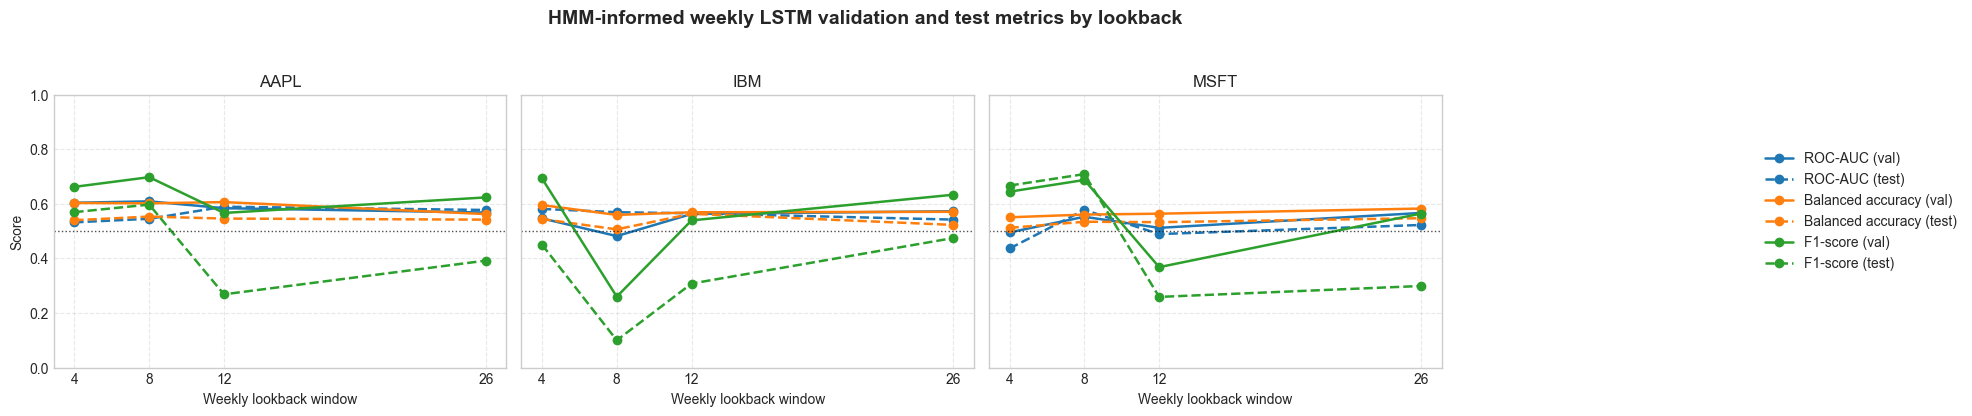

In [21]:
metric_cols = [
    "val_roc_auc",
    "test_roc_auc",
    "val_balanced_accuracy",
    "test_balanced_accuracy",
    "val_f1",
    "test_f1",
]

metric_plot_df = weekly_hmm_lstm_results_df.melt(
    id_vars=["ticker", "lookback"],
    value_vars=metric_cols,
    var_name="Metric_Split",
    value_name="Score",
)
metric_plot_df["Split"] = metric_plot_df["Metric_Split"].str.extract(r"^(val|test)_")
metric_plot_df["Metric"] = (
    metric_plot_df["Metric_Split"]
    .str.replace(r"^(val|test)_", "", regex=True)
    .replace({
        "roc_auc": "ROC-AUC",
        "balanced_accuracy": "Balanced accuracy",
        "f1": "F1-score",
    })
)

metric_colors = {
    "ROC-AUC": "tab:blue",
    "Balanced accuracy": "tab:orange",
    "F1-score": "tab:green",
}
split_styles = {
    "val": "-",
    "test": "--",
}

fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.8 * len(TICKERS), 4.2), sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = metric_plot_df.loc[metric_plot_df["ticker"] == ticker]
    for metric, color in metric_colors.items():
        for split, linestyle in split_styles.items():
            series = df_t.loc[(df_t["Metric"] == metric) & (df_t["Split"] == split)].sort_values("lookback")
            ax.plot(
                series["lookback"],
                series["Score"],
                marker="o",
                linestyle=linestyle,
                linewidth=1.8,
                color=color,
                label=f"{metric} ({split})",
            )

    ax.set_title(ticker)
    ax.set_xlabel("Weekly lookback window")
    ax.set_xticks(LOOKBACK_GRID)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1, alpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.45)

axes[0].set_ylabel("Score")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("HMM-informed weekly LSTM validation and test metrics by lookback", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.84, 0.94])
save_plot("weekly_hmm_lstm_metrics_by_lookback.png")
plt.show()
plt.close(fig)


### Baseline LSTM vs HMM-informed LSTM same-lookback deltas

This is the key incremental-value plot. A positive delta means that adding HMM regime features improved the LSTM relative to the baseline at the same lookback.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_same_lookback_deltas.png


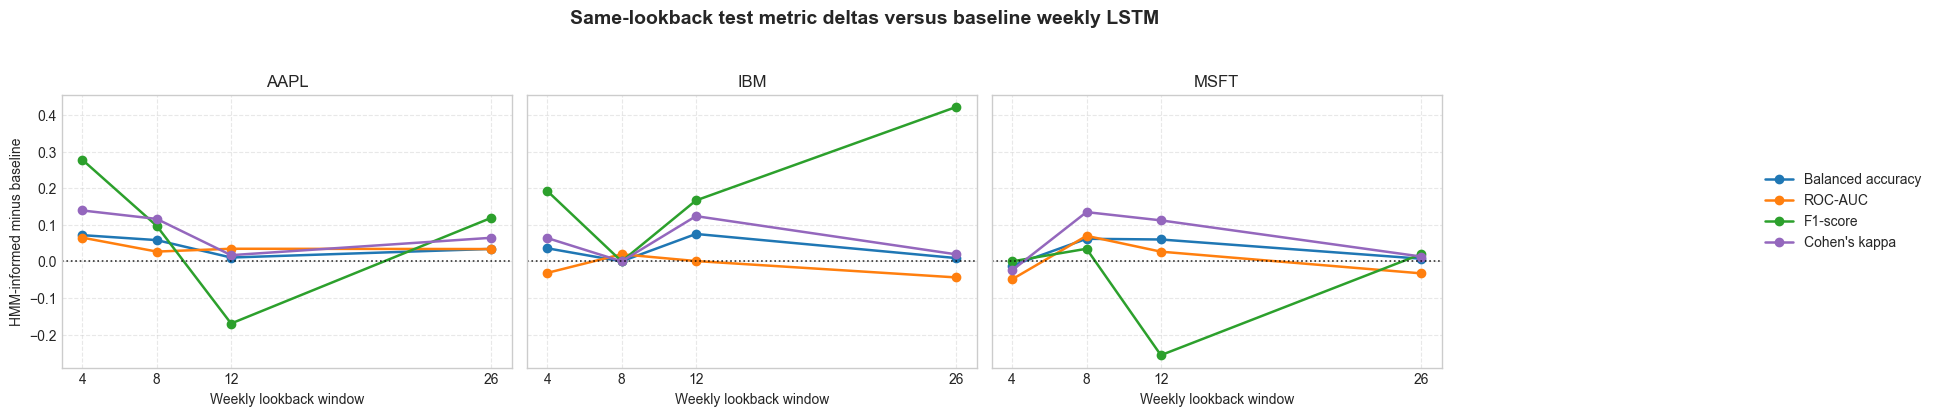

In [22]:
delta_metrics = [
    ("delta_test_balanced_accuracy", "Balanced accuracy"),
    ("delta_test_roc_auc", "ROC-AUC"),
    ("delta_test_f1", "F1-score"),
    ("delta_test_cohen_kappa", "Cohen's kappa"),
]
delta_colors = {
    "Balanced accuracy": "tab:blue",
    "ROC-AUC": "tab:orange",
    "F1-score": "tab:green",
    "Cohen's kappa": "tab:purple",
}

fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.8 * len(TICKERS), 4.2), sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = weekly_hmm_lstm_same_lookback_deltas_df.loc[
        weekly_hmm_lstm_same_lookback_deltas_df["Ticker"] == ticker
    ].sort_values("Lookback")
    for metric_col, label in delta_metrics:
        ax.plot(
            df_t["Lookback"],
            df_t[metric_col],
            marker="o",
            linewidth=1.8,
            color=delta_colors[label],
            label=label,
        )
    ax.axhline(0, color="black", linestyle=":", linewidth=1.2, alpha=0.8)
    ax.set_title(ticker)
    ax.set_xlabel("Weekly lookback window")
    ax.set_xticks(LOOKBACK_GRID)
    ax.grid(True, linestyle="--", alpha=0.45)

axes[0].set_ylabel("HMM-informed minus baseline")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Same-lookback test metric deltas versus baseline weekly LSTM", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.84, 0.94])
save_plot("weekly_hmm_lstm_same_lookback_deltas.png")
plt.show()
plt.close(fig)


### Delta summary by ticker

This plot summarizes whether the HMM features provide consistent incremental value across lookback windows for each ticker.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_delta_summary_by_ticker.png


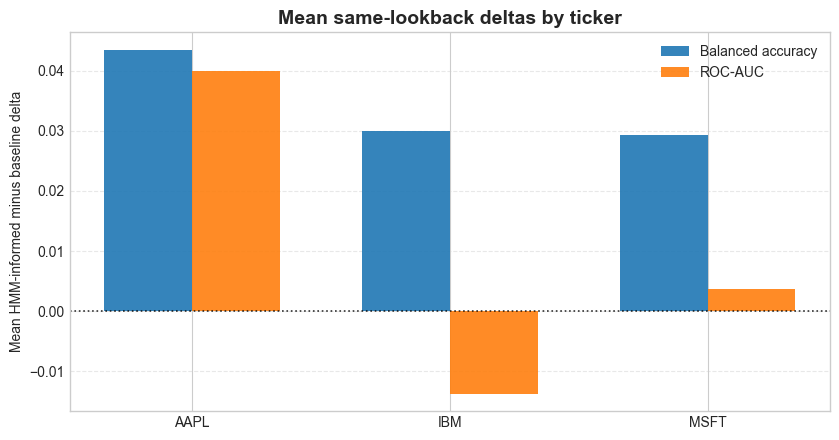

,Ticker,mean_delta_test_balanced_accuracy,mean_delta_test_roc_auc,mean_delta_test_f1,mean_delta_test_kappa,positive_delta_test_balanced_accuracy_share,lookback_count
0,AAPL,0.043555,0.039925,0.080950,0.084105,1.00,4
1,IBM,0.029913,-0.013795,0.195212,0.051637,0.75,4
2,MSFT,0.029259,0.003623,-0.050533,0.058867,0.75,4


In [23]:
summary_metrics = [
    ("mean_delta_test_balanced_accuracy", "Balanced accuracy"),
    ("mean_delta_test_roc_auc", "ROC-AUC"),
]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
x_positions = np.arange(len(weekly_hmm_lstm_delta_summary_by_ticker_df))
bar_width = 0.34
for idx, (metric_col, label) in enumerate(summary_metrics):
    offset = (idx - 0.5) * bar_width
    ax.bar(
        x_positions + offset,
        weekly_hmm_lstm_delta_summary_by_ticker_df[metric_col],
        width=bar_width,
        label=label,
        alpha=0.9,
    )

ax.axhline(0, color="black", linestyle=":", linewidth=1.2, alpha=0.8)
ax.set_xticks(x_positions)
ax.set_xticklabels(weekly_hmm_lstm_delta_summary_by_ticker_df["Ticker"])
ax.set_ylabel("Mean HMM-informed minus baseline delta")
ax.set_title("Mean same-lookback deltas by ticker", fontsize=14, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.45)
ax.legend(frameon=False)
fig.tight_layout()
save_plot("weekly_hmm_lstm_delta_summary_by_ticker.png")
plt.show()
plt.close(fig)

display(weekly_hmm_lstm_delta_summary_by_ticker_df)


### HMM-informed LSTM vs baseline, HMM-only, and benchmarks

This plot places the HMM-informed LSTM in the full modelling hierarchy: naive rules, HMM-only, baseline LSTM, and HMM-informed LSTM.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_model_comparison.png


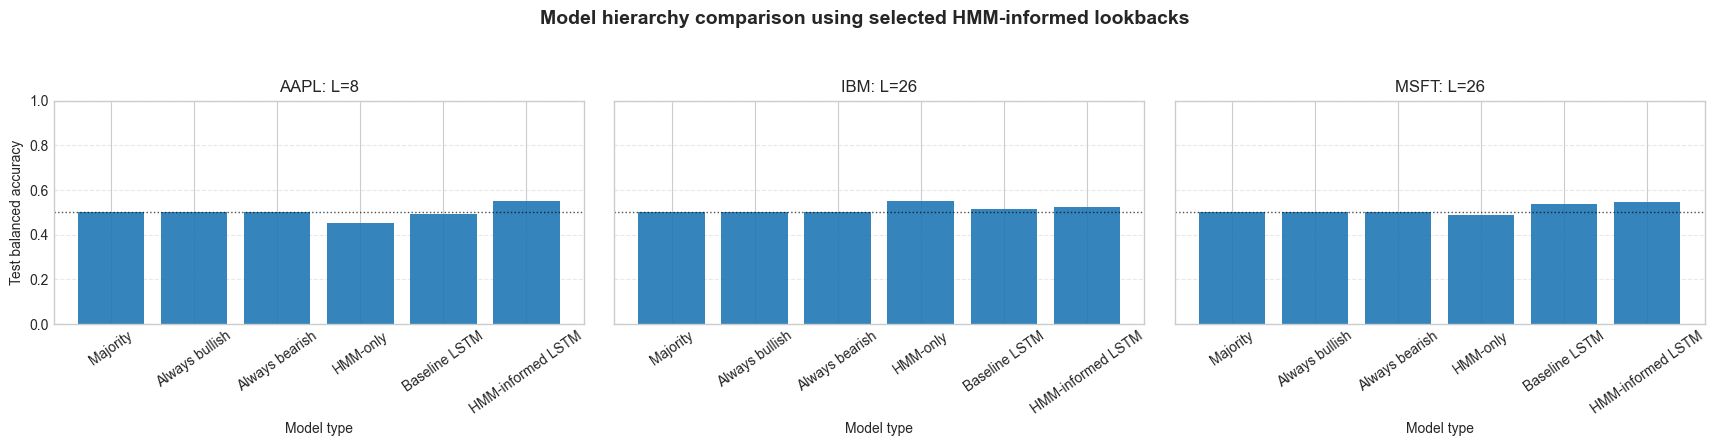

In [24]:
model_order = [
    "majority_class",
    "always_bullish",
    "always_bearish",
    "hmm_only",
    "baseline_weekly_lstm",
    "hmm_informed_weekly_lstm",
]
model_labels = {
    "majority_class": "Majority",
    "always_bullish": "Always bullish",
    "always_bearish": "Always bearish",
    "hmm_only": "HMM-only",
    "baseline_weekly_lstm": "Baseline LSTM",
    "hmm_informed_weekly_lstm": "HMM-informed LSTM",
}

comparison_records = []
for ticker in TICKERS:
    selected_lookback = selected_lookback_for_ticker(ticker)
    df_t = weekly_hmm_lstm_comparison_table_df.loc[weekly_hmm_lstm_comparison_table_df["Ticker"] == ticker].copy()
    for model in model_order:
        rows = df_t.loc[df_t["Model"] == model].copy()
        if rows.empty:
            continue
        if model in ["baseline_weekly_lstm", "hmm_informed_weekly_lstm"]:
            rows = rows.loc[rows["Lookback"].astype(float) == float(selected_lookback)]
        if rows.empty:
            continue
        row = rows.iloc[0]
        comparison_records.append(
            {
                "Ticker": ticker,
                "Model": model,
                "Model_Label": model_labels[model],
                "Selected_HMM_Lookback": selected_lookback,
                "Test_Balanced_Accuracy": row["Test balanced accuracy"],
            }
        )

comparison_plot_df = pd.DataFrame(comparison_records)

fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.8 * len(TICKERS), 4.5), sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = comparison_plot_df.loc[comparison_plot_df["Ticker"] == ticker].copy()
    df_t["Model"] = pd.Categorical(df_t["Model"], categories=model_order, ordered=True)
    df_t = df_t.sort_values("Model")
    ax.bar(df_t["Model_Label"], df_t["Test_Balanced_Accuracy"], alpha=0.9)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1, alpha=0.7)
    ax.set_title(f"{ticker}: L={selected_lookback_for_ticker(ticker)}")
    ax.set_xlabel("Model type")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", linestyle="--", alpha=0.45)

axes[0].set_ylabel("Test balanced accuracy")
fig.suptitle("Model hierarchy comparison using selected HMM-informed lookbacks", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_plot("weekly_hmm_lstm_model_comparison.png")
plt.show()
plt.close(fig)


### Selected-model confusion matrices

The confusion matrices show whether the selected model is making both Bullish and Bearish predictions, rather than collapsing to one class.


C:\Users\Admin\AppData\Local\Temp\ipykernel_3228\299041424.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.96, 0.92])


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_confusion_matrices.png


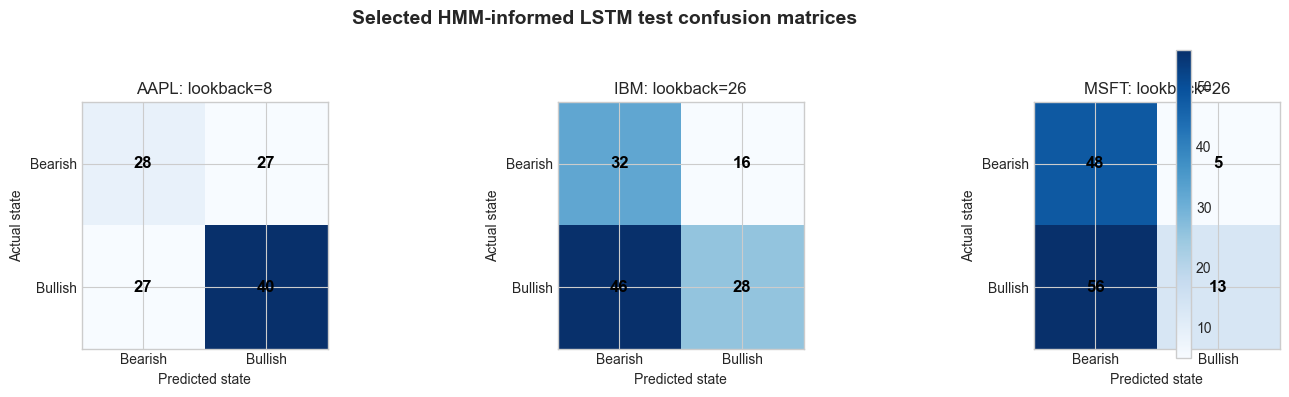

In [25]:
selected_test_df = selected_test_predictions()

fig, axes = plt.subplots(1, len(weekly_hmm_lstm_selected_models_df), figsize=(5 * len(weekly_hmm_lstm_selected_models_df), 4), sharex=False, sharey=False)
if len(weekly_hmm_lstm_selected_models_df) == 1:
    axes = [axes]

for ax, row in zip(axes, weekly_hmm_lstm_selected_models_df.itertuples(index=False)):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == row.ticker]
    cm = confusion_matrix(df_t["Target_State_Binary"], df_t["Predicted_State_Binary"], labels=[0, 1])

    image = ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=12, fontweight="bold")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Bearish", "Bullish"])
    ax.set_yticklabels(["Bearish", "Bullish"])
    ax.set_title(f"{row.ticker}: lookback={row.lookback}")
    ax.set_xlabel("Predicted state")
    ax.set_ylabel("Actual state")

fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02)
fig.suptitle("Selected HMM-informed LSTM test confusion matrices", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.96, 0.92])
save_plot("weekly_hmm_lstm_selected_confusion_matrices.png")
plt.show()
plt.close(fig)


### Selected-model ROC curves

ROC-AUC evaluates the ranking quality of predicted probabilities before choosing a hard classification threshold.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_roc_curves.png


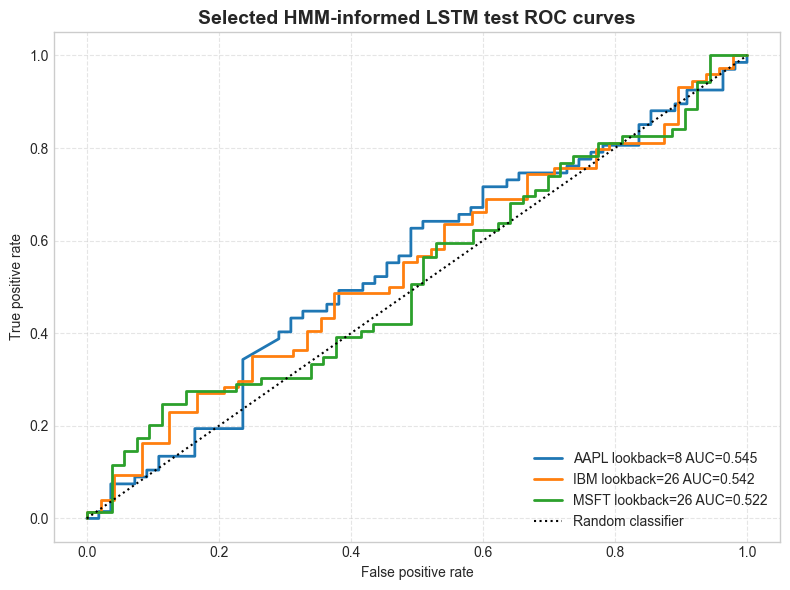

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
for row in weekly_hmm_lstm_selected_models_df.itertuples(index=False):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == row.ticker]
    y_true = df_t["Target_State_Binary"].astype(int)
    y_prob = df_t["Predicted_Bullish_Probability"].astype(float)
    if y_true.nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{row.ticker} lookback={row.lookback} AUC={roc_auc:.3f}")

ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1.5, label="Random classifier")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Selected HMM-informed LSTM test ROC curves", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
save_plot("weekly_hmm_lstm_selected_roc_curves.png")
plt.show()
plt.close(fig)


### Predicted probability distributions by true class

If the Bullish and Bearish distributions strongly overlap, the model has limited separation ability. If the distribution is concentrated around one value, the model may be weak or poorly calibrated.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_probability_distributions.png


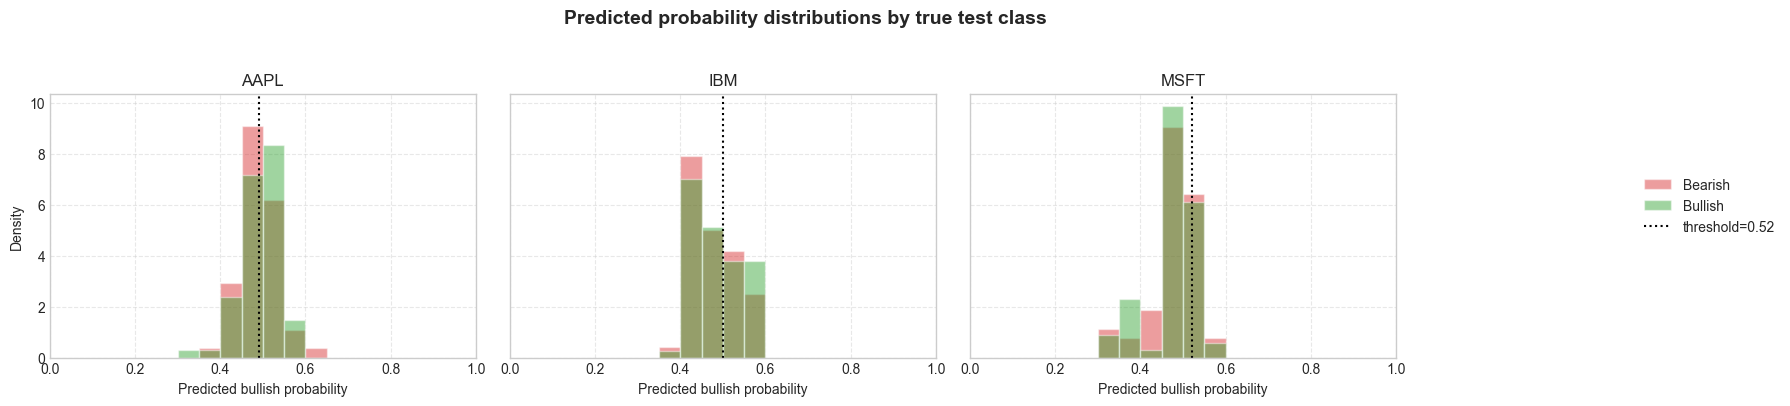

In [27]:
selected_test_df["Actual_State"] = np.where(selected_test_df["Target_State_Binary"] == 1, "Bullish", "Bearish")

fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.4 * len(TICKERS), 4.1), sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

bins = np.linspace(0, 1, 21)
for ax, ticker in zip(axes, TICKERS):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == ticker]
    decision_threshold = threshold_for_selected_ticker(ticker)
    for state in ["Bearish", "Bullish"]:
        values = df_t.loc[df_t["Actual_State"] == state, "Predicted_Bullish_Probability"]
        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.45,
            label=state,
            color=STATE_COLORS[state],
            edgecolor="white",
        )
    ax.axvline(decision_threshold, color="black", linestyle=":", linewidth=1.5, label=f"threshold={decision_threshold:.2f}")
    ax.set_xlim(0, 1)
    ax.set_title(ticker)
    ax.set_xlabel("Predicted bullish probability")
    ax.grid(True, linestyle="--", alpha=0.45)

axes[0].set_ylabel("Density")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Predicted probability distributions by true test class", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.88, 0.94])
save_plot("weekly_hmm_lstm_selected_probability_distributions.png")
plt.show()
plt.close(fig)


### Predicted probabilities over time

This plot helps inspect whether prediction errors cluster during certain market periods.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_probabilities_over_time.png


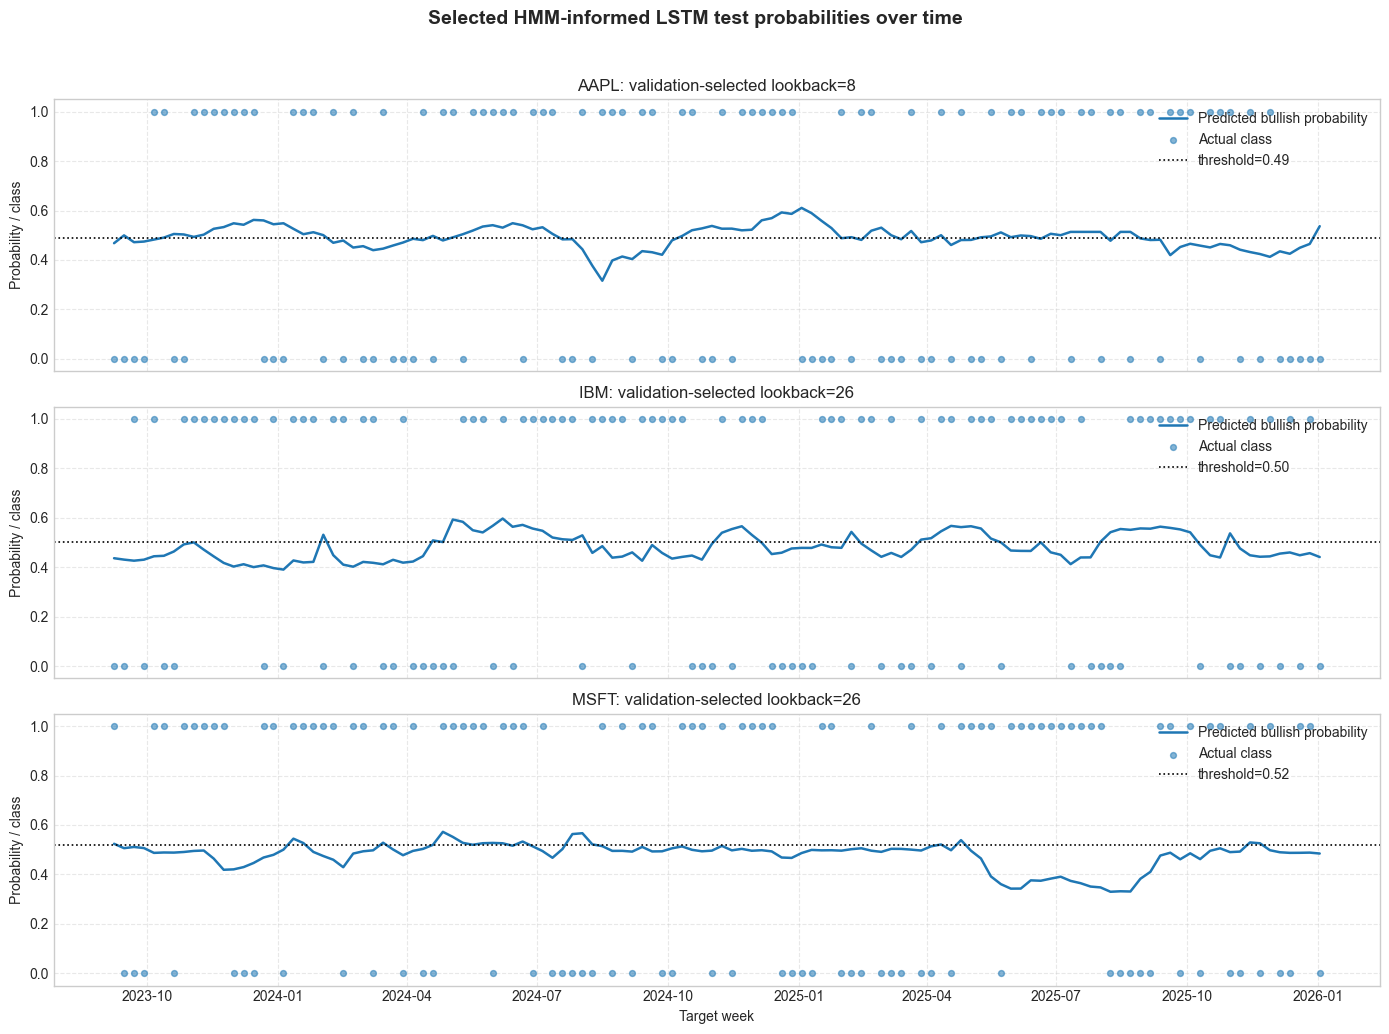

In [28]:
fig, axes = plt.subplots(len(weekly_hmm_lstm_selected_models_df), 1, figsize=(14, 3.5 * len(weekly_hmm_lstm_selected_models_df)), sharex=True, sharey=True)
if len(weekly_hmm_lstm_selected_models_df) == 1:
    axes = [axes]

for ax, row in zip(axes, weekly_hmm_lstm_selected_models_df.itertuples(index=False)):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == row.ticker].sort_values("Target_Date")
    decision_threshold = float(row.decision_threshold)
    ax.plot(df_t["Target_Date"], df_t["Predicted_Bullish_Probability"], linewidth=1.8, label="Predicted bullish probability")
    ax.scatter(
        df_t["Target_Date"],
        df_t["Target_State_Binary"],
        s=18,
        alpha=0.55,
        label="Actual class",
    )
    ax.axhline(decision_threshold, color="black", linestyle=":", linewidth=1.2, label=f"threshold={decision_threshold:.2f}")
    ax.set_title(f"{row.ticker}: validation-selected lookback={row.lookback}")
    ax.set_ylabel("Probability / class")
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.45)

axes[-1].set_xlabel("Target week")
fig.suptitle("Selected HMM-informed LSTM test probabilities over time", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_plot("weekly_hmm_lstm_selected_probabilities_over_time.png")
plt.show()
plt.close(fig)


### Training and validation loss curves

A large gap between training and validation loss suggests overfitting. A flat validation curve suggests limited learnable signal.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_training_loss.png


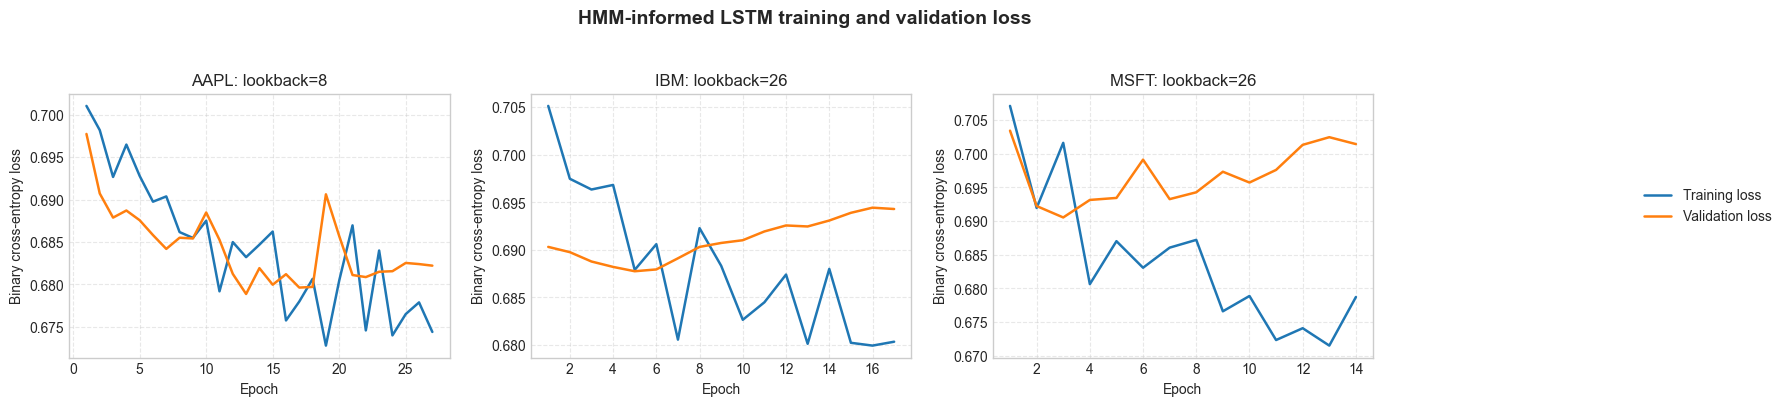

In [29]:
selected_keys_df = weekly_hmm_lstm_selected_models_df[["ticker", "lookback"]].copy()
selected_history_df = weekly_hmm_lstm_history_df.merge(selected_keys_df, on=["ticker", "lookback"], how="inner")

fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.4 * len(TICKERS), 4.1), sharey=False)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = selected_history_df.loc[selected_history_df["ticker"] == ticker].sort_values("epoch")
    if df_t.empty:
        ax.set_visible(False)
        continue
    lookback = int(df_t["lookback"].iloc[0])
    ax.plot(df_t["epoch"], df_t["loss"], linewidth=1.8, label="Training loss", color="tab:blue")
    ax.plot(df_t["epoch"], df_t["val_loss"], linewidth=1.8, label="Validation loss", color="tab:orange")
    ax.set_title(f"{ticker}: lookback={lookback}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Binary cross-entropy loss")
    ax.grid(True, linestyle="--", alpha=0.45)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("HMM-informed LSTM training and validation loss", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.86, 0.94])
save_plot("weekly_hmm_lstm_selected_training_loss.png")
plt.show()
plt.close(fig)


### Training and validation AUC curves

This plot shows whether the model improves beyond random ranking during training and whether validation AUC deteriorates after early epochs.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_training_auc.png


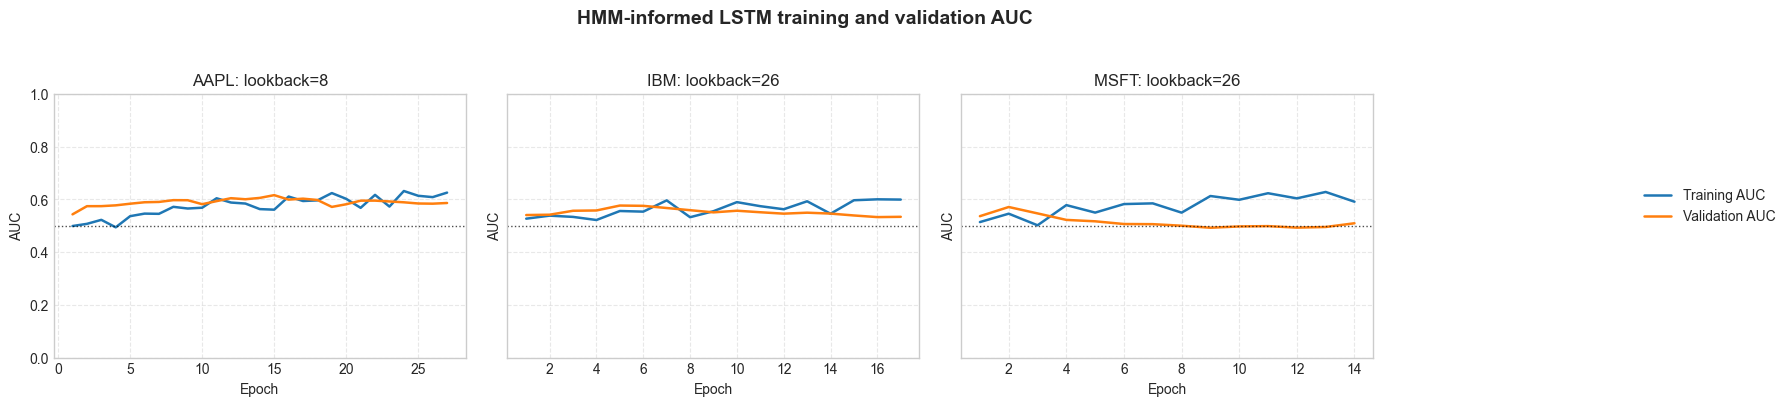

In [30]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.4 * len(TICKERS), 4.1), sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = selected_history_df.loc[selected_history_df["ticker"] == ticker].sort_values("epoch")
    if df_t.empty:
        ax.set_visible(False)
        continue
    lookback = int(df_t["lookback"].iloc[0])
    ax.plot(df_t["epoch"], df_t["auc"], linewidth=1.8, label="Training AUC", color="tab:blue")
    ax.plot(df_t["epoch"], df_t["val_auc"], linewidth=1.8, label="Validation AUC", color="tab:orange")
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1, alpha=0.7)
    ax.set_ylim(0, 1)
    ax.set_title(f"{ticker}: lookback={lookback}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("AUC")
    ax.grid(True, linestyle="--", alpha=0.45)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("HMM-informed LSTM training and validation AUC", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.86, 0.94])
save_plot("weekly_hmm_lstm_selected_training_auc.png")
plt.show()
plt.close(fig)


### HMM feature diagnostics over time

This plot shows whether the HMM-derived features vary meaningfully over time. If they are nearly flat, they may add limited information to the LSTM.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_hmm_features_over_time.png


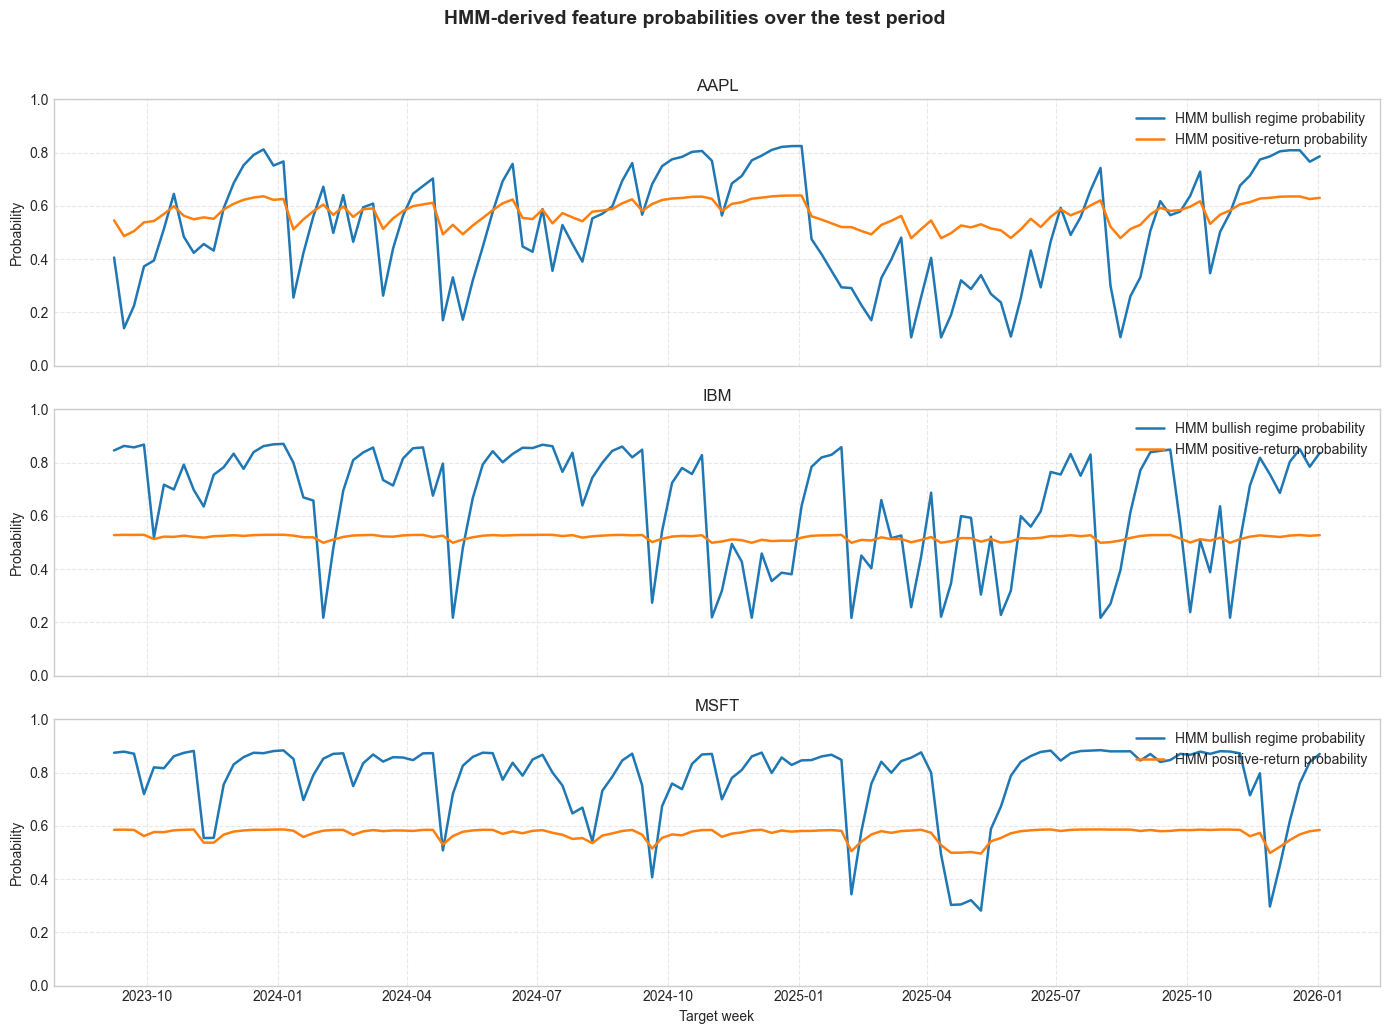

In [31]:
weekly_hmm_regime_features_df = pd.read_parquet(HMM_FEATURE_SOURCE_PATH)
for date_col in ["Date", "Target_Date"]:
    weekly_hmm_regime_features_df[date_col] = pd.to_datetime(weekly_hmm_regime_features_df[date_col])

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 3.5 * len(TICKERS)), sharex=True, sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = weekly_hmm_regime_features_df.loc[
        (weekly_hmm_regime_features_df["Ticker"] == ticker)
        & (weekly_hmm_regime_features_df["Split"] == "test")
    ].sort_values("Target_Date")
    ax.plot(df_t["Target_Date"], df_t["HMM_Bullish_Prob_Next"], linewidth=1.8, label="HMM bullish regime probability")
    ax.plot(df_t["Target_Date"], df_t["HMM_Positive_Return_Prob_Next"], linewidth=1.8, label="HMM positive-return probability")
    ax.set_ylim(0, 1)
    ax.set_title(ticker)
    ax.set_ylabel("Probability")
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Target week")
fig.suptitle("HMM-derived feature probabilities over the test period", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_plot("weekly_hmm_lstm_hmm_features_over_time.png")
plt.show()
plt.close(fig)


### Relationship between HMM probability and LSTM prediction

This plot checks whether the HMM-informed LSTM mostly follows the HMM probability or whether its predicted probabilities differ from the HMM-only signal.


Saved plot: d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_hmm_probability_vs_lstm_probability.png


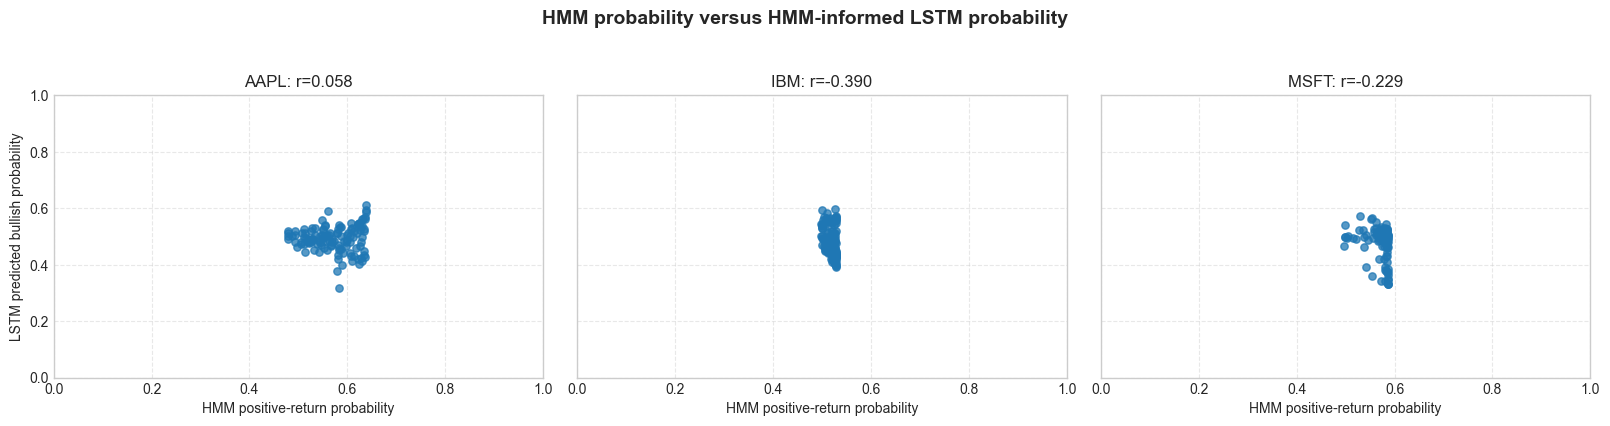

Pearson correlations between HMM positive-return probability and LSTM bullish probability:


,Ticker,Pearson_Correlation
0,AAPL,0.057977
1,IBM,-0.389599
2,MSFT,-0.228980


Saved plot files:
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_metrics_by_lookback.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_same_lookback_deltas.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_delta_summary_by_ticker.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_model_comparison.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_confusion_matrices.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_roc_curves.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_probability_distributions.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_probabilities_over_time.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\weekly_hmm_lstm_selected_training_loss.png
d:\BA_year_3\honour project\outputs\weekly_hmm_lstm\plots\w

In [32]:
hmm_probability_cols = ["Ticker", "Date", "Target_Date", "HMM_Bullish_Prob_Next", "HMM_Positive_Return_Prob_Next"]
selected_with_hmm_df = selected_test_df.merge(
    weekly_hmm_regime_features_df[hmm_probability_cols],
    on=["Ticker", "Date", "Target_Date"],
    how="left",
    validate="many_to_one",
)

if selected_with_hmm_df[["HMM_Bullish_Prob_Next", "HMM_Positive_Return_Prob_Next"]].isna().any().any():
    raise ValueError("Missing HMM probabilities after merging selected test predictions back to regime features.")

correlation_rows = []
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.4 * len(TICKERS), 4.3), sharex=True, sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = selected_with_hmm_df.loc[selected_with_hmm_df["Ticker"] == ticker]
    corr = df_t["HMM_Positive_Return_Prob_Next"].corr(df_t["Predicted_Bullish_Probability"])
    correlation_rows.append({"Ticker": ticker, "Pearson_Correlation": corr})
    ax.scatter(
        df_t["HMM_Positive_Return_Prob_Next"],
        df_t["Predicted_Bullish_Probability"],
        s=28,
        alpha=0.75,
    )
    ax.set_title(f"{ticker}: r={corr:.3f}")
    ax.set_xlabel("HMM positive-return probability")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.45)

axes[0].set_ylabel("LSTM predicted bullish probability")
fig.suptitle("HMM probability versus HMM-informed LSTM probability", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_plot("weekly_hmm_lstm_hmm_probability_vs_lstm_probability.png")
plt.show()
plt.close(fig)

correlation_df = pd.DataFrame(correlation_rows)
print("Pearson correlations between HMM positive-return probability and LSTM bullish probability:")
display(correlation_df)

print("Saved plot files:")
for path in saved_plot_paths:
    print(path)


## Research visualization summary

The research plots evaluate the HMM-informed LSTM from three perspectives. First, the lookback and delta plots show whether adding HMM regime probabilities improves the baseline LSTM at the same lookback. Second, the confusion matrices, ROC curves, probability distributions, and time-series probability plots inspect whether the selected models produce meaningful test-set classifications. Third, the training curves and HMM-feature diagnostics help assess whether the model learns stable information or whether the HMM inputs provide only weak incremental signal.

The main result should be interpreted through the same-lookback delta table and the selected-model test metrics, not through a single accuracy number.


## Final Sanity Checks

In [33]:
required_output_files = [
    OUTPUT_DIR / "weekly_hmm_lstm_results.csv",
    OUTPUT_DIR / "weekly_hmm_lstm_predictions.csv",
    OUTPUT_DIR / "hmm_lstm_sequence_metadata.csv",
    OUTPUT_DIR / "weekly_hmm_lstm_selected_models.csv",
    OUTPUT_DIR / "weekly_hmm_lstm_comparison_table.csv",
    OUTPUT_DIR / "weekly_hmm_lstm_same_lookback_deltas.csv",
    OUTPUT_DIR / "weekly_hmm_lstm_delta_summary_by_ticker.csv",
]

expected_sequence_files = [
    SEQUENCE_DIR / f"{ticker}_hmm_lstm_lookback_{lookback}.npz"
    for ticker in TICKERS
    for lookback in LOOKBACK_GRID
]
expected_model_files = [
    MODEL_DIR / f"weekly_hmm_lstm_{ticker}_lookback_{lookback}.keras"
    for ticker in TICKERS
    for lookback in LOOKBACK_GRID
]

missing_plot_files = [path for path in EXPECTED_PLOT_FILES if not path.exists()]
if missing_plot_files:
    raise FileNotFoundError(f"Missing saved plot files: {missing_plot_files}")

sanity_checks = {
    "HMM features loaded from weekly_hmm_regime_features.parquet": HMM_FEATURE_SOURCE_PATH.exists(),
    "HMM was not refitted in this notebook": "hmmlearn" not in sys.modules,
    "final augmented feature count is 17": len(AUGMENTED_LSTM_FEATURE_COLS) == EXPECTED_FEATURE_COUNT,
    "all sequence files exist": all(path.exists() for path in expected_sequence_files),
    "all 12 HMM-informed LSTM settings were trained": len(weekly_hmm_lstm_results_df) == EXPECTED_TRAINING_RUNS,
    "results table has 12 rows": pd.read_csv(OUTPUT_DIR / "weekly_hmm_lstm_results.csv").shape[0] == EXPECTED_TRAINING_RUNS,
    "selected models are based on validation metrics only": {"val_roc_auc", "val_balanced_accuracy", "val_f1"}.issubset(weekly_hmm_lstm_selected_models_df.columns),
    "no smoothed HMM probabilities are used": not any("smooth" in col.lower() for col in AUGMENTED_LSTM_FEATURE_COLS),
    "no target columns are included as features": not any(
        col in target_like_cols or col.lower().startswith("target") for col in AUGMENTED_LSTM_FEATURE_COLS
    ),
    "all required output CSVs exist": all(path.exists() for path in required_output_files),
    "all required plot files exist": all(path.exists() for path in EXPECTED_PLOT_FILES),
    "all model files exist": all(path.exists() for path in expected_model_files),
    "selected thresholds are saved": "decision_threshold" in weekly_hmm_lstm_results_df.columns and weekly_hmm_lstm_results_df["decision_threshold"].notna().all(),
    "warnings saved": {"degenerate_prediction_warning", "low_probability_variation_warning"}.issubset(weekly_hmm_lstm_results_df.columns),
}

sanity_df = pd.DataFrame(
    [{"Check": check, "Passed": bool(passed)} for check, passed in sanity_checks.items()]
)
display(sanity_df)

if not sanity_df["Passed"].all():
    failed = sanity_df.loc[~sanity_df["Passed"], "Check"].tolist()
    raise AssertionError(f"Final sanity checks failed: {failed}")

print("Training runs completed:", len(weekly_hmm_lstm_results_df))
print("Prediction rows:", len(weekly_hmm_lstm_predictions_df))
print("Expected plot files:", len(EXPECTED_PLOT_FILES))
print("All required HMM-informed LSTM research plots exist.")
print("All final sanity checks passed.")


,Check,Passed
0,HMM features loaded from weekly_hmm_regime_fea...,True
1,HMM was not refitted in this notebook,True
2,final augmented feature count is 17,True
3,all sequence files exist,True
4,all 12 HMM-informed LSTM settings were trained,True
5,results table has 12 rows,True
6,selected models are based on validation metric...,True
7,no smoothed HMM probabilities are used,True
8,no target columns are included as features,True
9,all required output CSVs exist,True


Training runs completed: 12
Prediction rows: 2916
Expected plot files: 12
All required HMM-informed LSTM research plots exist.
All final sanity checks passed.


## Final Interpretation

This notebook tests whether HMM-derived regime probabilities improve the weekly LSTM classifier. The HMM is not refitted here; instead, the notebook loads causal next-step probabilities from the standalone weekly HMM notebook. The HMM-informed LSTM uses the original 15 weekly technical features plus two HMM features: the next-week bullish-regime probability and the HMM-implied positive-return probability.

The target remains next-week direction. The model is evaluated against naive benchmarks, the baseline weekly LSTM, and the HMM-only benchmark. Model selection is based only on validation metrics, using validation ROC-AUC first, validation balanced accuracy second, and validation F1 third. Even if the HMM-informed LSTM does not improve test performance, the experiment is still useful because it directly tests whether causal regime context adds information beyond the baseline weekly technical features.
